In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales_dataset.csv")

In [2]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:
df.shape

(1000, 9)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [9]:
df["Month"] = df["Date"].dt.month_name()

In [10]:
df[["Date","Month"]].head()

,Date,Month
0,2023-11-24,November
1,2023-02-27,February
2,2023-01-13,January
3,2023-05-21,May
4,2023-05-06,May


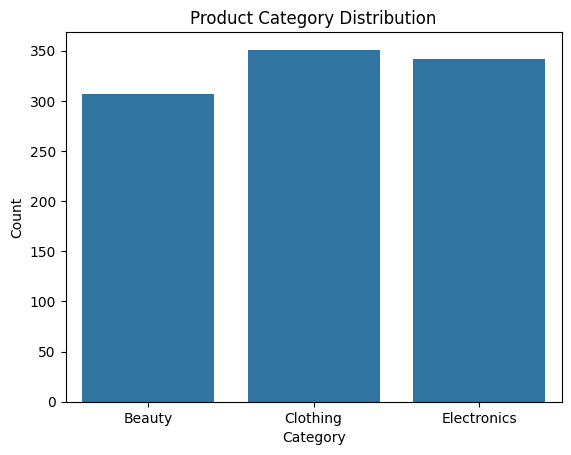

In [11]:
#Visualization — Product Category Distribution

plt.Figure(figsize=(8,5))
sns.countplot(
  x="Product Category",
  data=df
)

plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [12]:
df["Product Category"].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

In [13]:
# Revenue by Product Category - value calc

category_sales = df.groupby("Product Category")["Total Amount"].sum()
print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


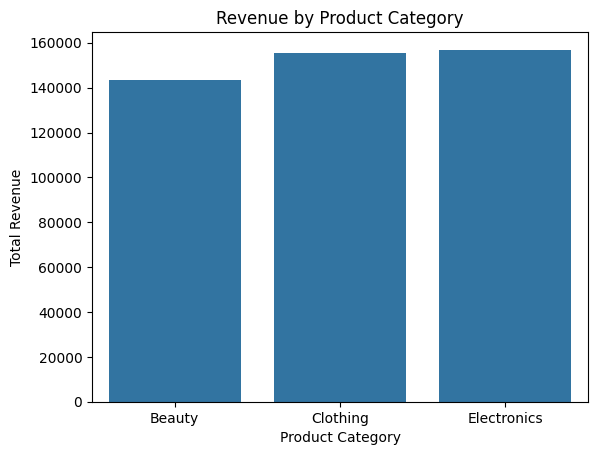

In [15]:
# Visualisation - Revenue by Product Category

plt.Figure(figsize=(8,5))
sns.barplot(
  x=category_sales.index,
  y=category_sales.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

In [16]:
df["Gender"].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

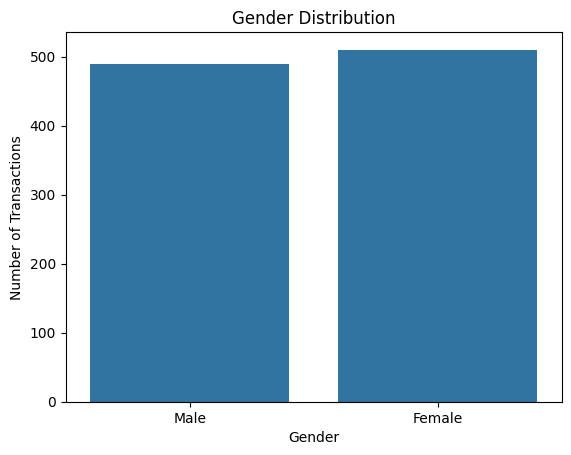

In [17]:
plt.Figure(figsize=(6,4))
sns.countplot(
  x="Gender",
  data=df
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.show()

In [19]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()
print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


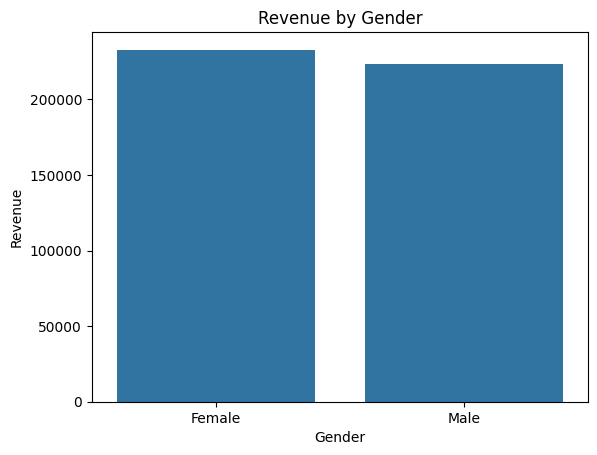

In [20]:
plt.Figure(figsize=(6,4))
sns.barplot(
  x=gender_sales.index,
  y=gender_sales.values
)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.show()

In [21]:
df["Age"].describe()

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64

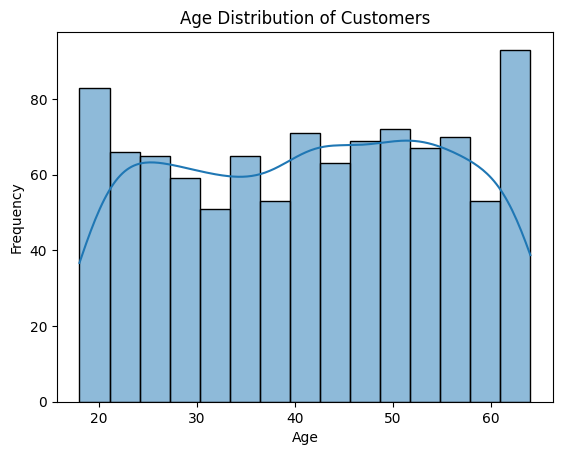

In [23]:
plt.Figure(figsize=(8,5))
sns.histplot(
  df["Age"],
  bins=15,
  kde=True
)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [24]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
print(monthly_sales)

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64


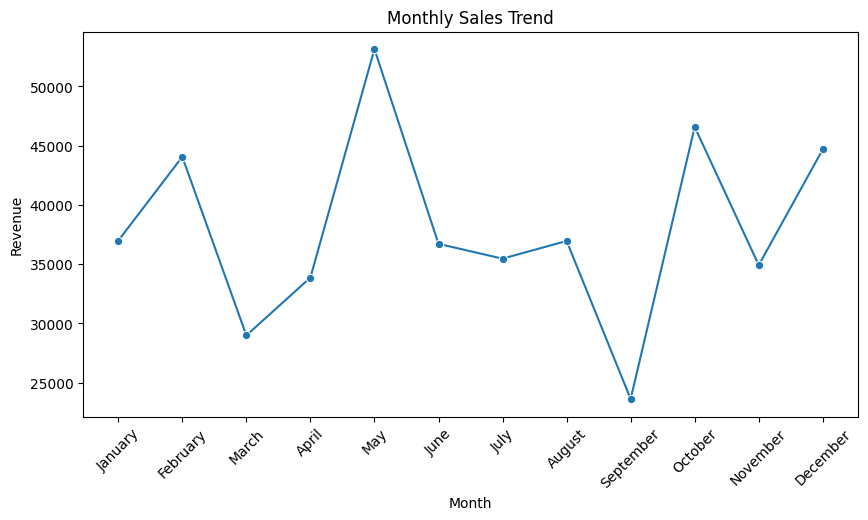

In [25]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = df.groupby("Month")["Total Amount"].sum().reindex(month_order)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.show()

In [26]:
df.corr(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.000000,0.065191,-0.026623,-0.060837,-0.075034
Age,0.065191,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.026623,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.060837,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.075034,-0.060568,0.373707,0.851925,1.000000


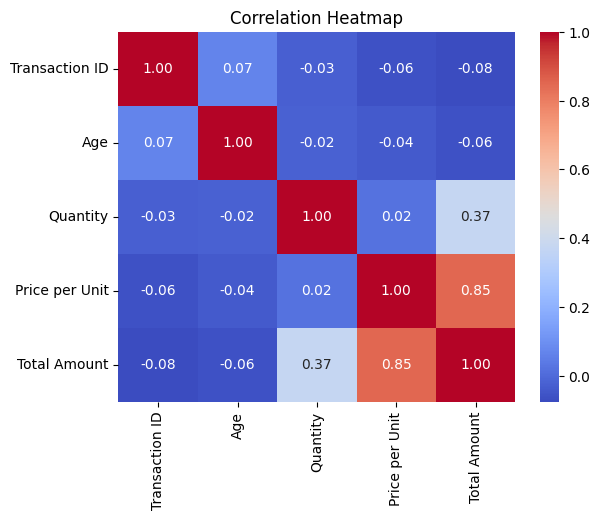

In [27]:
plt.Figure(figsize=(8,6))

corr = df.corr(numeric_only=True)
sns.heatmap(
  corr,
  annot=True,
  cmap="coolwarm",
  fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()